Capstone Project:The business objective is to develop a predictive model that identifies diabetic patients at high risk of hospital readmission within 30 days of discharge. This model aims to enable healthcare providers to implement targeted interventions, improve patient outcomes, reduce healthcare costs associated with preventable readmissions, and optimize resource allocation.

# Capstone Project: Initial Report and Exploratory Data Analysis (EDA)

**Overview**: In this practical application, goal perform the Exploratory Data Analysis of data :Predicting Hospital Readmission within 30 Days : Diabetic patient readmissions within 30 days of discharge

Research data considered :
Predicting Hospital Readmission within 30 Days : Diabetic patient readmissions within 30 days of discharge represent a critical and costly issue for healthcare systems. These preventable readmissions significantly strain hospital resources, lead to substantial financial penalties, and most importantly, compromise patient well-being and recovery. Identifying patients at highest risk of readmission relies heavily on subjective assessments, leading to inefficient resource allocation and missed opportunities for timely intervention. This project leverages advanced machine learning techniques on a rich historical dataset of diabetic patient hospitalizations to develop a predictive model. This model will accurately identify patients at elevated risk of 30-day readmission upon discharge

Dataset Name: Diabetes 130-US hospitals for years 1999-2008 Data Set

Source: UCI Machine Learning Repository

Link : https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008Links to an external site.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008).  The data is from Hospital Readmission within 30 Days : Diabetic patient readmissions within 30 days of discharge represent a critical and costly issue for healthcare systems. These preventable readmissions significantly strain hospital resources, lead to substantial financial penalties, and most importantly, compromise patient well-being and recovery. Identifying patients at highest risk of readmission relies heavily on subjective assessments, leading to inefficient resource allocation and missed opportunities for timely intervention.


### Problem 1: Understanding the Data

Exploratory Data Analysis of Diabetic Readmissions Data
This section will perform Exploratory Data Analysis (EDA) on the 'Diabetic 130-US Hospitals for Years 1999-2008' dataset from the UCI Machine Learning Repository. The goal is to understand the dataset's structure, identify missing values, examine data distributions, and uncover potential patterns.

In [8]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

# URL to the data folder
data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip'
zip_file_name = 'dataset_diabetes.zip'
data_file_name = 'diabetic_data.csv'
# Download the zip file
!wget $data_url -O $zip_file_name

# Unzip the file
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('./data')

--2026-04-30 14:39:07--  https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘dataset_diabetes.zip’

dataset_diabetes.zi     [ <=>                ]   3.19M  --.-KB/s    in 0.1s    

2026-04-30 14:39:07 (32.7 MB/s) - ‘dataset_diabetes.zip’ saved [3347213]



### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [9]:


# Load the dataset with the corrected path
df = pd.read_csv(os.path.join('./data', 'dataset_diabetes', data_file_name))

print(f"Dataset '{data_file_name}' loaded successfully. Shape: {df.shape}")

Dataset 'diabetic_data.csv' loaded successfully. Shape: (101766, 50)


In [10]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Problem 3: Understanding the Features

Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.

Now that the `diabetic_data.csv` has been loaded, let's understand its structure and content. We will look at column names, data types, non-null counts, and identify potential missing values, which are often represented by '?' in this dataset. We'll also examine descriptive statistics for numerical columns and unique values for categorical columns.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

Data Information and Missing Values
Next, we'll check the data types of each column and identify any missing values. According to the dataset description, '?' indicates missing values, so we'll treat them as such.

In [12]:
print("\nNumber of '?' values in each column:")
for column in df.columns:
    if (df[column] == '?').any():
        count = (df[column] == '?').sum()
        print(f"{column}: {count}")

# Count total '?' values across the entire DataFrame
total_missing_q_values = (df == '?').sum().sum()
print(f"\nTotal '?' values in the DataFrame: {total_missing_q_values}")


Number of '?' values in each column:
race: 2273
weight: 98569
payer_code: 40256
medical_specialty: 49949
diag_1: 21
diag_2: 358
diag_3: 1423

Total '?' values in the DataFrame: 192849


In [13]:
# Drop columns with a large number of missing '?' values
columns_to_drop = ['weight', 'medical_specialty']
df = df.drop(columns=columns_to_drop)

print(f"Columns {columns_to_drop} dropped. New DataFrame shape: {df.shape}")

Columns ['weight', 'medical_specialty'] dropped. New DataFrame shape: (101766, 48)


In [14]:
# Display descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df.describe())


Descriptive statistics for numerical columns:


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [15]:
# Display unique values and their counts for categorical columns
print("\nUnique values and their counts for categorical columns:")
for column in df.select_dtypes(include='object').columns:
    print(f"\n--- {column} ---")
    display(df[column].value_counts())


Unique values and their counts for categorical columns:

--- race ---


,count
race,
Caucasian,76099
AfricanAmerican,19210
?,2273
Hispanic,2037
Other,1506
Asian,641



--- gender ---


,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3



--- age ---


...

,count
change,
No,54755
Ch,47011



--- diabetesMed ---


,count
diabetesMed,
Yes,78363
No,23403



--- readmitted ---


,count
readmitted,
NO,54864
>30,35545
<30,11357


In [16]:
for column in ['payer_code', 'diag_1', 'diag_2', 'diag_3']:
    # Replace '?' with numpy's NaN
    df[column] = df[column].replace('?', np.nan)

    # Get the mode of the column
    col_mode = df[column].mode()[0]

    # Impute missing values with the mode
    df[column] = df[column].fillna(col_mode)

    print(f"Missing '?' values in '{column}' column replaced with its mode: {col_mode}")
    print(f"New count of '?' in '{column}': {(df[column] == '?').sum()}\n")

# Verify no more '?' values exist in the DataFrame
total_missing_q_values = (df == '?').sum().sum()
print(f"Total '?' values remaining in the DataFrame: {total_missing_q_values}")

Missing '?' values in 'payer_code' column replaced with its mode: MC
New count of '?' in 'payer_code': 0

Missing '?' values in 'diag_1' column replaced with its mode: 428
New count of '?' in 'diag_1': 0

Missing '?' values in 'diag_2' column replaced with its mode: 276
New count of '?' in 'diag_2': 0

Missing '?' values in 'diag_3' column replaced with its mode: 250
New count of '?' in 'diag_3': 0

Total '?' values remaining in the DataFrame: 2273


In [17]:
# Replace '?' with numpy's NaN for easier handling of missing values
df['race'] = df['race'].replace('?', np.nan)

# Get the mode of the 'race' column
race_mode = df['race'].mode()[0]

# Impute missing 'race' values with the mode
df['race'] = df['race'].fillna(race_mode)

print(f"Missing '?' values in 'race' column replaced with its mode: {race_mode}")
print(f"New count of '?' in 'race': {(df['race'] == '?').sum()}")

Missing '?' values in 'race' column replaced with its mode: Caucasian
New count of '?' in 'race': 0


In [18]:
print("\nRemaining null values after '?' replacement:")
print(df[['max_glu_serum', 'A1Cresult']].isnull().sum())


Remaining null values after '?' replacement:
max_glu_serum    96420
A1Cresult        84748
dtype: int64


In [19]:
# Fill NaN values in 'max_glu_serum' and 'A1Cresult' with 'None'
df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
df['A1Cresult'] = df['A1Cresult'].fillna('None')

print("Null values after filling:")
print(df[['max_glu_serum', 'A1Cresult']].isnull().sum())

Null values after filling:
max_glu_serum    0
A1Cresult        0
dtype: int64


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   admission_type_id         101766 non-null  int64 
 6   discharge_disposition_id  101766 non-null  int64 
 7   admission_source_id       101766 non-null  int64 
 8   time_in_hospital          101766 non-null  int64 
 9   payer_code                101766 non-null  object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [21]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("Dropping duplicate rows...")
    df.drop_duplicates(inplace=True)
    print(f"New DataFrame shape after dropping duplicates: {df.shape}")

Number of duplicate rows: 0


In [22]:
# Display data types to check for inconsistencies
print("\nDataFrame info after cleaning:")
df.info()


DataFrame info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   admission_type_id         101766 non-null  int64 
 6   discharge_disposition_id  101766 non-null  int64 
 7   admission_source_id       101766 non-null  int64 
 8   time_in_hospital          101766 non-null  int64 
 9   payer_code                101766 non-null  object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         1

### Exploring Categorical Features

Let's begin by examining the distribution of the target variable, `readmitted`.

Distribution of 'readmitted' column:


,count
readmitted,
NO,54864
>30,35545
<30,11357


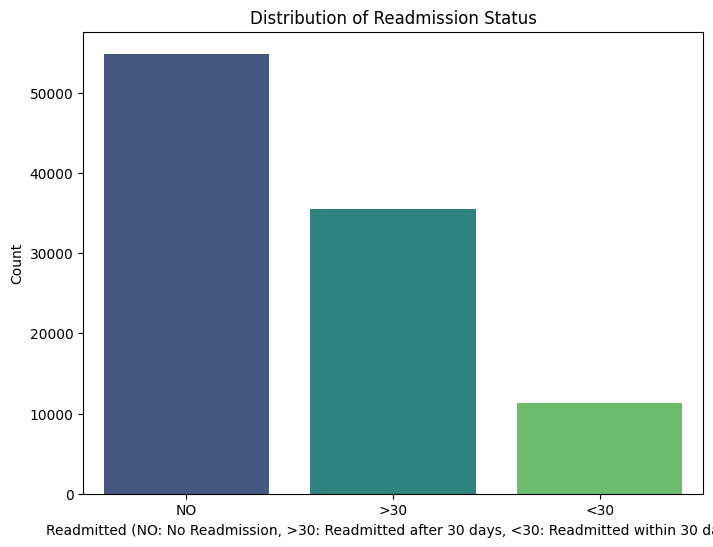

In [23]:
print("Distribution of 'readmitted' column:")
display(df['readmitted'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='readmitted', data=df, hue='readmitted', palette='viridis', legend=False)
plt.title('Distribution of Readmission Status')
plt.xlabel('Readmitted (NO: No Readmission, >30: Readmitted after 30 days, <30: Readmitted within 30 days)')
plt.ylabel('Count')
plt.show()

Next, let's explore the distribution of 'gender'.

Distribution of 'gender' column:


,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3


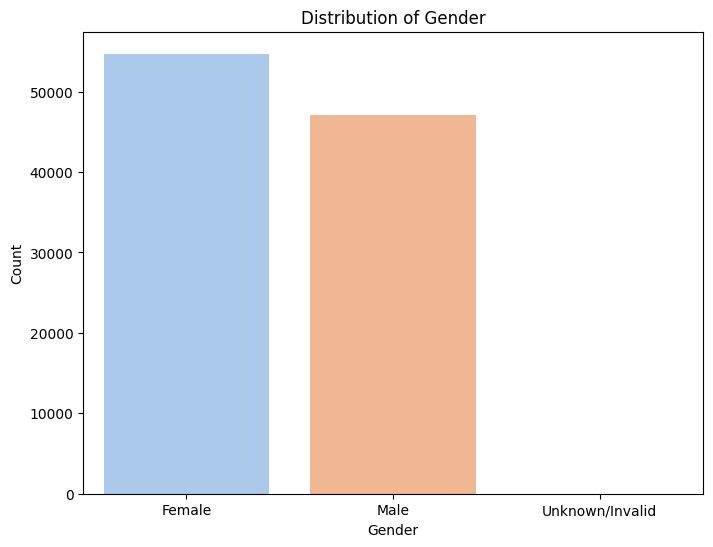

In [24]:
print("Distribution of 'gender' column:")
display(df['gender'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='gender', data=df, hue='gender', palette='pastel', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Now, let's look at the 'age' distribution.

Distribution of 'age' column:


,count
age,
[0-10),161
[10-20),691
[20-30),1657
[30-40),3775
[40-50),9685
[50-60),17256
[60-70),22483
[70-80),26068
[80-90),17197


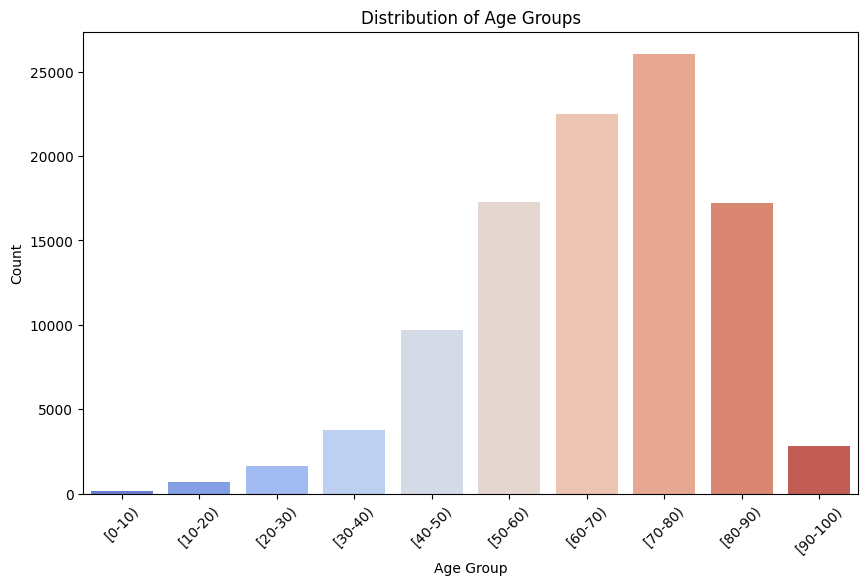

In [25]:
print("Distribution of 'age' column:")
display(df['age'].value_counts().sort_index())

plt.figure(figsize=(10, 6))
sns.countplot(x='age', data=df, hue='age', palette='coolwarm', order=sorted(df['age'].unique()), legend=False)
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

Now that we have explored some categorical features, we will move to Problem 5: Engineering Features to prepare our data for modeling.

For Problem 5: Engineering Features, we will focus on transforming our raw data into a format suitable for machine learning models. This typically involves:

1.  **Encoding Categorical Variables:** Many features like 'race', 'gender', 'age', 'payer_code', and drug-related columns are categorical. We'll need to convert these into numerical representations using techniques like one-hot encoding or label encoding.
2.  **Handling Numerical Features:** While most numerical features appear clean, we might consider scaling them if necessary, especially for models sensitive to feature scales.
3.  **Target Variable Transformation:** The 'readmitted' column needs to be converted into a binary target (e.g., 0 for no readmission, 1 for readmission within 30 days).
4.  **Feature Selection/Creation:** Based on our EDA, we might identify features that are highly correlated with the target or create new features that could improve model performance.

### Encoding Categorical Features: 'gender' and 'age'

Reasoning: The next step in exploratory data analysis is to generate descriptive statistics for numerical columns to understand their distribution and central tendencies. The df.describe() method is perfect for this.


In [26]:
print("Descriptive Statistics for Numerical Columns:")
print(df.describe())

Descriptive Statistics for Numerical Columns:
       encounter_id   patient_nbr  admission_type_id  \
count  1.017660e+05  1.017660e+05      101766.000000   
mean   1.652016e+08  5.433040e+07           2.024006   
std    1.026403e+08  3.869636e+07           1.445403   
min    1.252200e+04  1.350000e+02           1.000000   
25%    8.496119e+07  2.341322e+07           1.000000   
50%    1.523890e+08  4.550514e+07           1.000000   
75%    2.302709e+08  8.754595e+07           3.000000   
max    4.438672e+08  1.895026e+08           8.000000   

       discharge_disposition_id  admission_source_id  time_in_hospital  \
count             101766.000000        101766.000000     101766.000000   
mean                   3.715642             5.754437          4.395987   
std                    5.280166             4.064081          2.985108   
min                    1.000000             1.000000          1.000000   
25%                    1.000000             1.000000          2.000000   
50%  

Reasoning: To analyze the distribution of categorical features, I need to identify them first and then print their value counts to see the unique categories and their frequencies.


In [27]:
print("Distribution of Categorical Features:")
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Distribution of Categorical Features:

Column: race
race
Caucasian          78372
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

Column: gender
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

Column: age
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

Column: payer_code
payer_code
MC    72695
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
PO      592
DM      549
CH      146
WC      135
OT       95
MP       79
SI       55
FR        1
Name: count, dtype: int64

Column: diag_1
diag_1
428    6883
414    6581
786    4016
410    3614
486    3508
       ... 
412       1
363       1
957       1
976       1
V51       1
Name: count, Length: 716, dty

In [28]:
import pandas as pd
import numpy as np
import os

# Define data_file_name (from cell OF4VMak6q7DL)
data_file_name = 'diabetic_data.csv'

# Load the dataset from scratch to ensure a clean state
# Assuming the 'data' directory with 'dataset_diabetes' is already present
# after previous execution which downloads and unzips the data.
df = pd.read_csv(os.path.join('./data', 'dataset_diabetes', data_file_name))

# Re-apply previous data cleaning steps to reconstruct 'df' state
# Drop columns with a large number of missing '?' values (from cell 269213c3)
columns_to_drop = ['weight', 'medical_specialty']
df = df.drop(columns=columns_to_drop)

# Impute '?' with mode for specific columns (from cell 9d81e495)
for column in ['payer_code', 'diag_1', 'diag_2', 'diag_3']:
    df[column] = df[column].replace('?', np.nan)
    col_mode = df[column].mode()[0]
    df[column] = df[column].fillna(col_mode)

# Impute '?' in 'race' with mode (from cell ffbad830)
df['race'] = df['race'].replace('?', np.nan)
race_mode = df['race'].mode()[0]
df['race'] = df['race'].fillna(race_mode)

# Fill NaN values in 'max_glu_serum' and 'A1Cresult' with 'None' (from cell 2e471dc9)
df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
df['A1Cresult'] = df['A1Cresult'].fillna('None')

# Handle 'gender' column (from cell 4862d657)
# Remove rows with 'Unknown/Invalid' gender as they are very few (3 entries)
df = df[df['gender'] != 'Unknown/Invalid']
print(f"DataFrame shape after removing 'Unknown/Invalid' gender entries: {df.shape}")

# One-hot encode 'gender'
df = pd.get_dummies(df, columns=['gender'], prefix='gender', drop_first=True)
print(f"DataFrame shape after one-hot encoding 'gender': {df.shape}")

# Apply 'age' ordinal encoding
age_mapping = {'[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45,
               '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95}
df['age'] = df['age'].map(age_mapping)

print("Age column after ordinal encoding:")
display(df['age'].value_counts().sort_index())

print("First 5 rows of DataFrame after verifying 'age' encoding:")
display(df.head())

DataFrame shape after removing 'Unknown/Invalid' gender entries: (101763, 48)
DataFrame shape after one-hot encoding 'gender': (101763, 48)
Age column after ordinal encoding:


,count
age,
5,161
15,691
25,1657
35,3775
45,9685
55,17256
65,22482
75,26066
85,17197


First 5 rows of DataFrame after verifying 'age' encoding:


,encounter_id,patient_nbr,race,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,gender_Male
0,2278392,8222157,Caucasian,5,6,25,1,1,MC,41,...,No,No,No,No,No,No,No,No,NO,False
1,149190,55629189,Caucasian,15,1,1,7,3,MC,59,...,Up,No,No,No,No,No,Ch,Yes,>30,False
2,64410,86047875,AfricanAmerican,25,1,1,7,2,MC,11,...,No,No,No,No,No,No,No,Yes,NO,False
3,500364,82442376,Caucasian,35,1,1,7,2,MC,44,...,Up,No,No,No,No,No,Ch,Yes,NO,True
4,16680,42519267,Caucasian,45,1,1,7,1,MC,51,...,Steady,No,No,No,No,No,Ch,Yes,NO,True


### Correlation Heatmap for Numerical Columns

Let's visualize the correlation between the numerical features to identify any strong relationships.

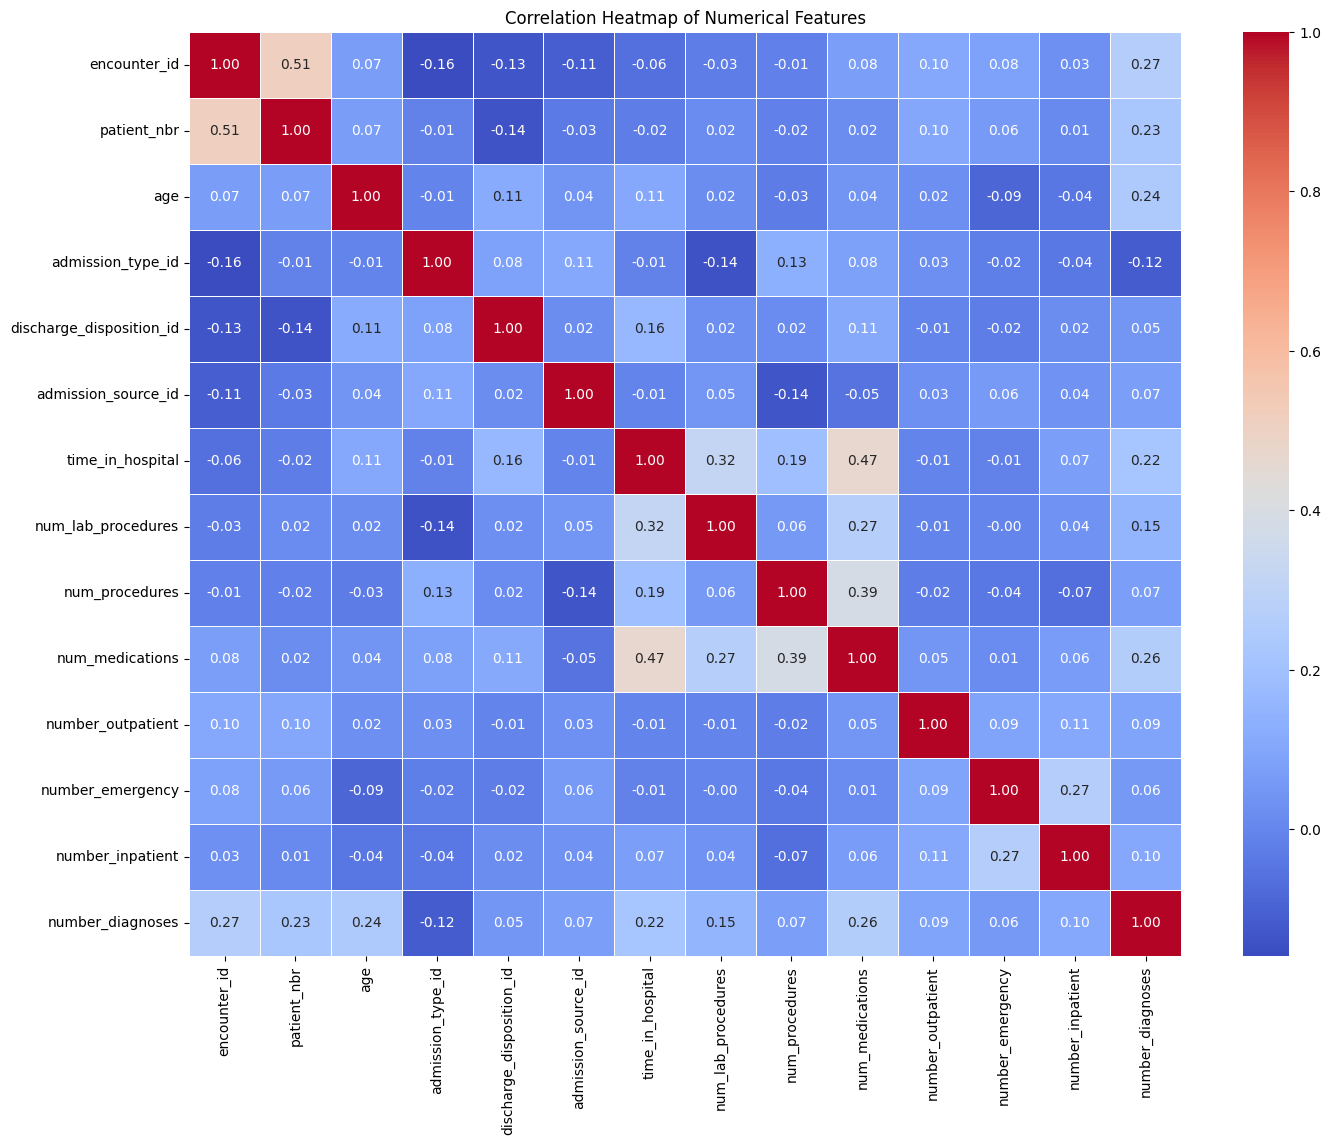

In [29]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Calculate the correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Reasoning: To visualize numerical distributions, I need to plot histograms for each numerical column. I will use matplotlib.pyplot and seaborn for this, ensuring proper titles and layouts.


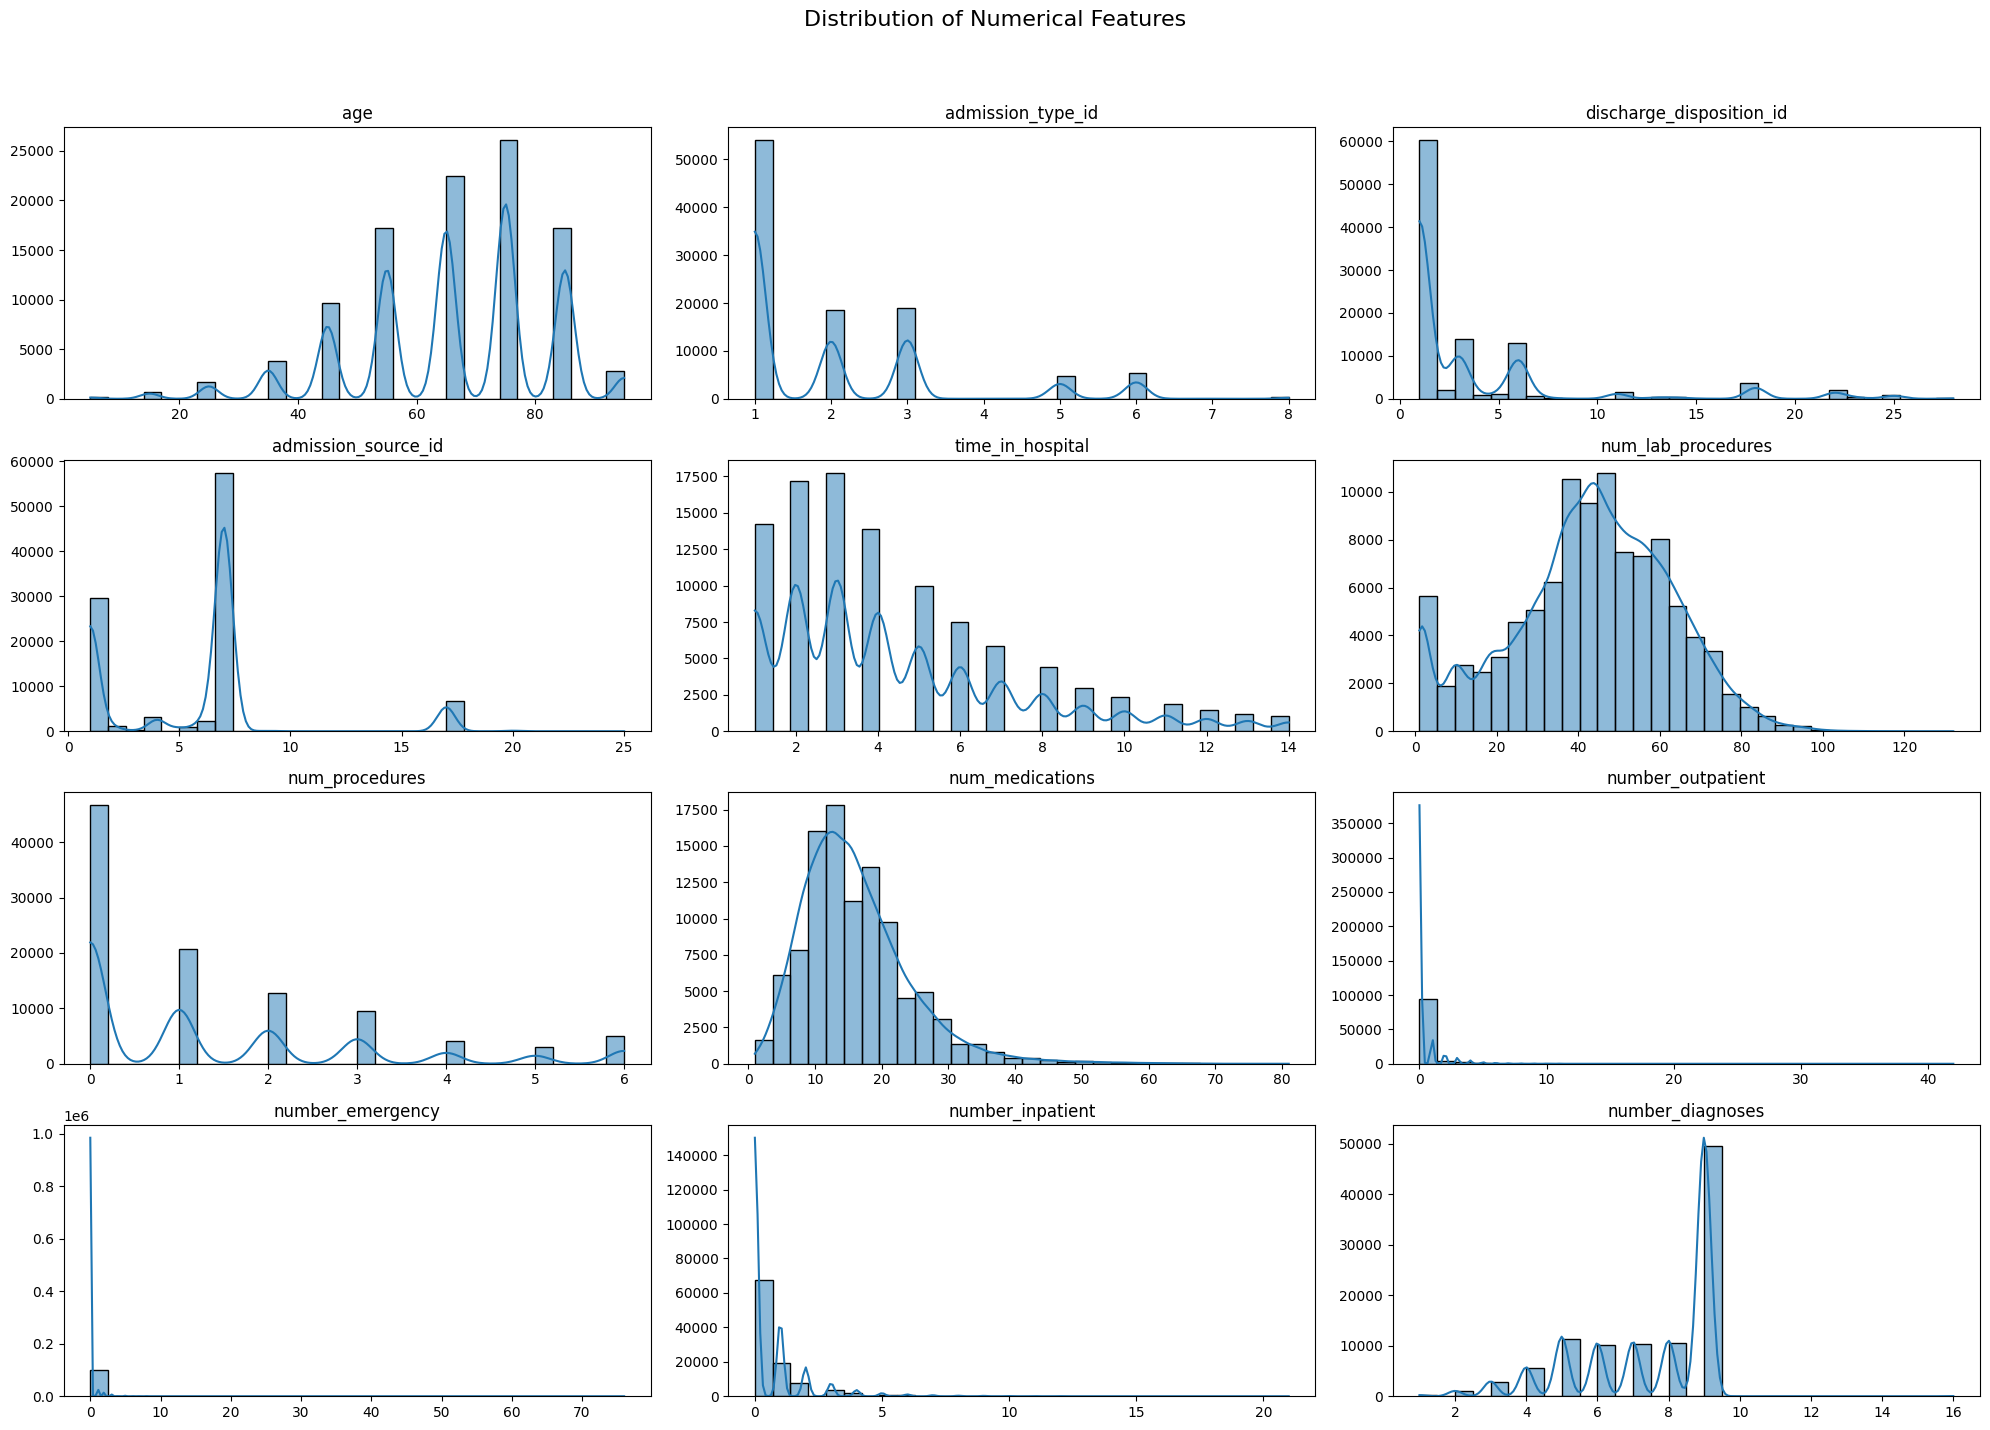

In [30]:
# Plot histograms for numerical features

# Identify numerical columns from X (excluding identifier columns)
numerical_cols_for_hist = [col for col in X.select_dtypes(include=np.number).columns if col not in ['encounter_id', 'patient_nbr']]

# Set up the matplotlib figure and axes
fig = plt.figure(figsize=(20, 15))
fig.suptitle('Distribution of Numerical Features', fontsize=16)

for i, col in enumerate(numerical_cols_for_hist):
    ax = fig.add_subplot(4, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df_processed[col], kde=True, ax=ax, bins=30) # Using df_processed as it has age encoded
    ax.set_title(col)
    ax.set_xlabel('') # Remove x-label to avoid clutter
    ax.set_ylabel('') # Remove y-label to avoid clutter

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent titles from overlapping
plt.show()

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Create a copy of the DataFrame to work with for processing
df_processed = df.copy()

# Convert the 'readmitted' column into a binary target variable
# 1 if readmitted within 30 days ('<30'), 0 otherwise ('NO', '>30')
df_processed['readmitted_binary'] = df_processed['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Drop the original 'readmitted' column as we now have 'readmitted_binary'
df_processed = df_processed.drop('readmitted', axis=1)

# Separate features (X) and target (y)
X = df_processed.drop('readmitted_binary', axis=1)
y = df_processed['readmitted_binary']

# Identify categorical and numerical columns for transformation based on X
categorical_features = X.select_dtypes(include='object').columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove identifier columns from numerical features if they are not meant for scaling/modeling
id_cols = ['encounter_id', 'patient_nbr']
numerical_features = [col for col in numerical_features if col not in id_cols]

print("Features (X) and Target (y) prepared for transformation.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Create a column transformer for preprocessing (but don't fit_transform yet)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns not explicitly transformed, if any
)


Features (X) and Target (y) prepared for transformation.
Shape of X: (101763, 47)
Shape of y: (101763,)


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [32]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (81410, 2373)
Shape of X_test: (20353, 2373)
Shape of y_train: (81410,)
Shape of y_test: (20353,)


In [34]:
from sklearn.metrics import classification_report

# Generate the classification report for the baseline model
baseline_report = classification_report(y_test, baseline_predictions, zero_division=0)

print("Classification Report for Baseline Model:")
print(baseline_report)

Classification Report for Baseline Model:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.00      0.00      0.00      2271

    accuracy                           0.89     20353
   macro avg       0.44      0.50      0.47     20353
weighted avg       0.79      0.89      0.84     20353



### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

Majority class in training set: 0
Baseline Accuracy (predicting majority class 0): 0.8884

Baseline Confusion Matrix:
[[18082     0]
 [ 2271     0]]


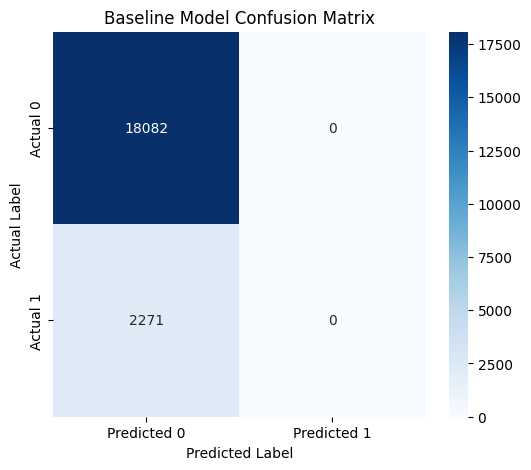

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Determine the majority class in the training set
majority_class = y_train.mode()[0]
print(f"Majority class in training set: {majority_class}")

# Create baseline predictions (always predict the majority class)
baseline_predictions = [majority_class] * len(y_test)

# Calculate baseline accuracy
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
print(f"Baseline Accuracy (predicting majority class {majority_class}): {baseline_accuracy:.4f}")

# Generate confusion matrix for the baseline model
baseline_cm = confusion_matrix(y_test, baseline_predictions)
print("\nBaseline Confusion Matrix:")
print(baseline_cm)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(baseline_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Baseline Model Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Interpreting the Baseline Confusion Matrix

*   **True Negatives (TN):** Top-left value. These are cases where the model correctly predicted 0 (no readmission).
*   **False Positives (FP):** Top-right value. These are cases where the model incorrectly predicted 1 (readmission) when the actual value was 0.
*   **False Negatives (FN):** Bottom-left value. These are cases where the model incorrectly predicted 0 (no readmission) when the actual value was 1.
*   **True Positives (TP):** Bottom-right value. These are cases where the model correctly predicted 1 (readmission).

For a baseline model that always predicts the majority class (which is `0` in our case, meaning no readmission), the confusion matrix will show:

*   A large number in the **True Negatives** (TN) cell, corresponding to all the actual 0s that were correctly predicted as 0.
*   A large number in the **False Negatives** (FN) cell, corresponding to all the actual 1s that were incorrectly predicted as 0.
*   **Zero** in the **False Positives** (FP) cell, because the model never predicts 1.
*   **Zero** in the **True Positives** (TP) cell, because the model never predicts 1.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [35]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
logistic_model = LogisticRegression(solver='liblinear', random_state=42)

# Train the model on the training data
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Problem 9: Score the Model

What is the accuracy of your model?

Model Accuracy: 0.8884

Model Confusion Matrix:
[[18082     0]
 [ 2271     0]]


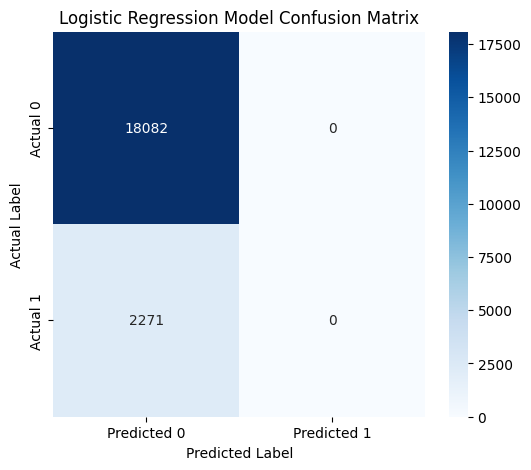


Classification Report for Logistic Regression Model:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.00      0.00      0.00      2271

    accuracy                           0.89     20353
   macro avg       0.44      0.50      0.47     20353
weighted avg       0.79      0.89      0.84     20353



In [36]:
# Make predictions on the test set
y_pred = logistic_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Generate and display the confusion matrix
model_cm = confusion_matrix(y_test, y_pred)
print("\nModel Confusion Matrix:")
print(model_cm)

plt.figure(figsize=(6, 5))
sns.heatmap(model_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Logistic Regression Model Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Generate and display the classification report
model_report = classification_report(y_test, y_pred, zero_division=0)
print("\nClassification Report for Logistic Regression Model:")
print(model_report)

### Improving the Model: Addressing Class Imbalance with Class Weights

As observed, the initial Logistic Regression model performed no better than the baseline in predicting readmissions (the minority class). This is a common issue with imbalanced datasets. One way to mitigate this is by using `class_weight='balanced'` in the Logistic Regression model. This parameter automatically adjusts weights inversely proportional to class frequencies in the input data, effectively telling the model to pay more attention to the minority class.

Logistic Regression model trained with balanced class weights successfully.

Model Accuracy (with balanced class weights): 0.5831

Model Confusion Matrix (with balanced class weights):
[[10921  7161]
 [ 1325   946]]


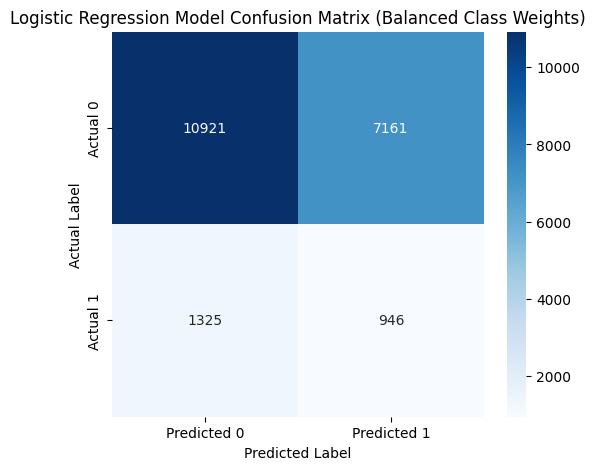


Classification Report for Logistic Regression Model (Balanced Class Weights):
              precision    recall  f1-score   support

           0       0.89      0.60      0.72     18082
           1       0.12      0.42      0.18      2271

    accuracy                           0.58     20353
   macro avg       0.50      0.51      0.45     20353
weighted avg       0.81      0.58      0.66     20353



In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Re-initialize the Logistic Regression model with class_weight='balanced'
# This will automatically adjust weights inversely proportional to class frequencies
logistic_model_balanced = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced', max_iter=1000)

# Train the model on the training data
logistic_model_balanced.fit(X_train, y_train)

print("Logistic Regression model trained with balanced class weights successfully.")

# Make predictions on the test set
y_pred_balanced = logistic_model_balanced.predict(X_test)

# Calculate accuracy
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
print(f"\nModel Accuracy (with balanced class weights): {accuracy_balanced:.4f}")

# Generate and display the confusion matrix
model_cm_balanced = confusion_matrix(y_test, y_pred_balanced)
print("\nModel Confusion Matrix (with balanced class weights):")
print(model_cm_balanced)

plt.figure(figsize=(6, 5))
sns.heatmap(model_cm_balanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Logistic Regression Model Confusion Matrix (Balanced Class Weights)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Generate and display the classification report
model_report_balanced = classification_report(y_test, y_pred_balanced, zero_division=0)
print("\nClassification Report for Logistic Regression Model (Balanced Class Weights):")
print(model_report_balanced)

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

##### Questions